# Cleaner

While our preprocessing has removed obvious anomalies (e.g. useless/unknown characters), some data can't really be used in our ML Model and EDA. 

Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Extracting our preprocessed datasets 

In [4]:
path_prefix = '../p03_preprocessing/data/'

def load_with_id(path):
    df = pd.read_csv(path)
    if 'Unnamed: 0' in df.columns:
        df = df.rename(columns={'Unnamed: 0': 'id'})
    return df

labels = load_with_id(f'{path_prefix}01_binding_labels.csv')
naive_features = load_with_id(f'{path_prefix}02_naive_processed_features.csv')
conjoint_triads = load_with_id(f'{path_prefix}03_conjoint_triads_processed_features.csv')
global_features = load_with_id(f'{path_prefix}04_antibody_only_physicochemical_properties.csv')

## 01 - Labels Subdataset

Checking the preprocessed `labels` dataset and the values

In [5]:
labels.head(2)

,id,is_binding_SARS-CoV2_WT,is_neutral_SARS-CoV2_WT,is_nanobody,name
0,0,1,1,0,Curtis_3548_S-2
1,1,1,0,0,Curtis_3548_S-7


In [6]:
binding_counts = labels['is_binding_SARS-CoV2_WT'].value_counts()
neutral_counts = labels['is_neutral_SARS-CoV2_WT'].value_counts()
nano_counts = labels['is_nanobody'].value_counts()

summary_df = pd.concat([binding_counts, neutral_counts, nano_counts], axis=1)

summary_df.columns = ['Binding', 'Neutralization', 'Is Nanobody']
summary_df.index.name = 'Class Value'
summary_df = summary_df.fillna(0).astype(int) # Fill NaNs (like where nanobody only has 0/1)

print("Dataset Class Balance Summary:")
print(summary_df)

Dataset Class Balance Summary:
             Binding  Neutralization  Is Nanobody
Class Value                                      
1              11267            5563         1218
0               5629            8059        16700
2               1022            4296            0


Notice how we have class value of `2` which means unknown. We **cannot** use unknown features in our dataset for both EDA and especially the ML model. Hence, we remove all instances where the binding class and neutral classes' value is equal to `2`

In [7]:
labels_cleaned = labels[(labels['is_binding_SARS-CoV2_WT'] != 2) & 
                (labels['is_neutral_SARS-CoV2_WT'] != 2)]
labels_cleaned.shape

(12746, 5)

To check that they are successfully removed:

In [8]:
binding_counts = labels_cleaned['is_binding_SARS-CoV2_WT'].value_counts()
neutral_counts = labels_cleaned['is_neutral_SARS-CoV2_WT'].value_counts()
nano_counts = labels_cleaned['is_nanobody'].value_counts()

summary_df = pd.concat([binding_counts, neutral_counts, nano_counts], axis=1)

summary_df.columns = ['Binding', 'Neutralization', 'Is Nanobody']
summary_df.index.name = 'Class Value'
summary_df = summary_df.fillna(0).astype(int) # Fill NaNs (like where nanobody only has 0/1)

print("Dataset Class Balance Summary:")
print(summary_df)

Dataset Class Balance Summary:
             Binding  Neutralization  Is Nanobody
Class Value                                      
1               7494            5420          805
0               5252            7326        11941


As shown, we have successfully removed all instances with a value of `2` in the binding class or neutral class.

Additionally, a neutralizer **must** be a binder. So, checking on this

In [ ]:
## TODO: the same thing as earlier, the Venn Diagram even w/o the diagram, just the counts of how many are in each category (binding only, neutralization only, both, neither)

NameError: name 'df_cleaned' is not defined

This cleaned dataset will then be saved in the `/cleaned_data` folder

In [9]:
output_path = Path("cleaned_data/01_binding_labels_cleaned.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
labels_cleaned.to_csv(output_path)
print(f"Saved cleaned labels to {output_path}")

Saved cleaned labels to cleaned_data/01_binding_labels_cleaned.csv


## 02 - Naive Processed Features

In [10]:
naive_features.head(2)

,id,CDRH3_len,CDRH3_amino_acid_percentage_A,CDRH3_amino_acid_percentage_C,CDRH3_amino_acid_percentage_D,CDRH3_amino_acid_percentage_E,CDRH3_amino_acid_percentage_F,CDRH3_amino_acid_percentage_G,CDRH3_amino_acid_percentage_H,CDRH3_amino_acid_percentage_I,...,VHorVHH_amino_acid_percentage_V,VHorVHH_amino_acid_percentage_W,VHorVHH_amino_acid_percentage_Y,S_RBD,S_NTD,S_S2,S_S1,N_Protein,Other_Spike,Unknown
0,0,13,0.076923,0.0,0.230769,0.000000,0.076923,0.076923,0.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0
1,1,14,0.071429,0.0,0.071429,0.071429,0.000000,0.214286,0.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0


**Feature Definitions**
* **CDRH3/CDRL3**: The hyper-variable loops (fingers) that directly contact the antigen. CDRH3 is the primary driver of binding.
* **VHorVHH/VL**: The structural framework (hand) that supports the CDR loops. VHH refers specifically to Nanobody domains.
* **Physicochemical Stats**: Global metrics like `charge`, `hydrophobicity`, and `aromaticity` that describe the chemical environment of the binding interface.

All antibodies should have CDRH3 and VHorVHH. CDRL3 and VL can be 0 as nanobodies usually do not have these.

In [11]:
# 1. Remove rows where length is 0 (useless for training)
naive_features_cleaned = naive_features[(naive_features['CDRH3_len'] > 0) &
                                        (naive_features['VHorVHH_len'] > 0)]

# Missing Value (if there are) to NaN
naive_features_cleaned = naive_features_cleaned.fillna(0)

naive_features_cleaned.shape

(17918, 92)

In addition, in each feature, their percentages should sum up to 1 as well (0 for VL and CDRL3)). Considering rounding errors, we decided to do a margin of error of 1e-6.

In [12]:
tolerance = 1e-6

# - CDRH3 and VHorVHH must sum to 1
# - CDRL3 and VL may sum to 0 (missing) or 1 (present)
sum_rules = {
    "CDRH3": "one_only",
    "VHorVHH": "one_only",
    "CDRL3": "zero_or_one",
    "VL": "zero_or_one",
}

invalid_rows_by_group = {}
invalid_index_union = set()

for group, rule in sum_rules.items():
    cols = [c for c in naive_features_cleaned.columns if c.startswith(f"{group}_amino_acid_percentage_")]
    group_sum = naive_features_cleaned[cols].sum(axis=1)
    group_sum_df = group_sum.rename(f"{group}_sum").to_frame()

    print(f"\n=== {group} ===")
    print("Sum stats:", group_sum.describe().loc[['min', 'max', 'mean']].to_dict())

    if rule == "one_only":
        invalid_mask = ~group_sum.sub(1).abs().le(tolerance)
        expected_msg = "1"
    else:  # zero_or_one
        is_zero = group_sum.abs().le(tolerance)
        is_one = group_sum.sub(1).abs().le(tolerance)
        invalid_mask = ~(is_zero | is_one)
        expected_msg = "0 or 1"

    invalid_rows = group_sum_df.loc[invalid_mask]
    invalid_rows_by_group[group] = invalid_rows
    invalid_index_union.update(invalid_rows.index.tolist())

    print(f"Invalid rows (expected {expected_msg}): {len(invalid_rows)}")
    if not invalid_rows.empty:
        display(invalid_rows)

invalid_index_union = sorted(invalid_index_union)
print(f"\nTotal unique invalid rows to remove: {len(invalid_index_union)}")

naive_features_validated = naive_features_cleaned.drop(index=invalid_index_union)
print("Shape before removal:", naive_features_cleaned.shape)
print("Shape after removal:", naive_features_validated.shape)


=== CDRH3 ===
Sum stats: {'min': 0.9166666666666664, 'max': 1.0000000000000004, 'mean': 0.9999423201952693}
Invalid rows (expected 1): 19


,CDRH3_sum
6020,0.956522
8601,0.916667
8768,0.960000
9096,0.950000
9097,0.947368
9098,0.947368
9099,0.928571
9100,0.952381
9101,0.937500
9102,0.954545



=== VHorVHH ===
Sum stats: {'min': 0.9898989898989898, 'max': 1.0000000000000004, 'mean': 0.9999974194787994}
Invalid rows (expected 1): 5


,VHorVHH_sum
1199,0.990196
1200,0.989899
1201,0.990196
1736,0.991736
17795,0.991736



=== CDRL3 ===
Sum stats: {'min': 0.0, 'max': 1.0000000000000002, 'mean': 0.931113628773626}
Invalid rows (expected 0 or 1): 5


,CDRL3_sum
6020,0.928571
8601,0.909091
9137,0.900000
10639,0.056338
17195,0.900000



=== VL ===
Sum stats: {'min': 0.0, 'max': 1.0000000000000002, 'mean': 0.9315208436315695}
Invalid rows (expected 0 or 1): 1


,VL_sum
1948,0.990476



Total unique invalid rows to remove: 28
Shape before removal: (17918, 92)
Shape after removal: (17890, 92)


This discrepancy does not necessarily mean that the original data is **incorrect**. Rather, it indicates that the biological sequence likely contains nonstandard or unknown amino acids that a standard 20-amino-acid frequency calculation cannot account for.

**Rationale for Removal:**
* **Unresolved Sequences:** A frequency sum of `< 1.0` is a direct biophysical indicator that the sequence contains ambiguous or unrecognized characters (e.g., `X`, `B`, or `Z`). 
* **Model Validity:** The CDR loops are the primary drivers of antigen binding. Feeding a machine learning model mathematically incomplete data introduces critical blind spots. Dropping these rows ensures the model trains exclusively on structurally complete and definitively identified sequences.

This cleaned dataset will then be saved in the `/cleaned_data` folder

In [13]:
output_path = Path("cleaned_data/02_naive_processed_features_cleaned.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
naive_features_validated.to_csv(output_path, index=False)
print(f"Saved cleaned features to {output_path}")

Saved cleaned features to cleaned_data/02_naive_processed_features_cleaned.csv


## 03 - Conjoint Triads (wtf)

In [14]:
conjoint_triads.head(10)

,id,name,CDRH3_CTD_111,CDRH3_CTD_112,CDRH3_CTD_113,CDRH3_CTD_114,CDRH3_CTD_115,CDRH3_CTD_116,CDRH3_CTD_117,CDRH3_CTD_121,...,VHorVHH_CTD_765,VHorVHH_CTD_766,VHorVHH_CTD_767,VHorVHH_CTD_771,VHorVHH_CTD_772,VHorVHH_CTD_773,VHorVHH_CTD_774,VHorVHH_CTD_775,VHorVHH_CTD_776,VHorVHH_CTD_777
0,0,Curtis_3548_S-2,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,Curtis_3548_S-7,0.0,0.000000,0.000000,0.0,0.083333,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Curtis_3548_RBD-15,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,8-D9,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,Sun_1G11,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,8F4P,0.0,0.000000,0.000000,0.0,0.125000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,NIV-1,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,7,NIV-5,0.0,0.071429,0.071429,0.0,0.000000,0.071429,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8,NIV-6,0.0,0.000000,0.000000,0.0,0.083333,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,NIV-8,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
conjoint_triads.shape

(17918, 1374)

This one has a lot of columns.

In [16]:
conjoint_triads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17918 entries, 0 to 17917
Columns: 1374 entries, id to VHorVHH_CTD_777
dtypes: float64(1372), int64(1), object(1)
memory usage: 187.8+ MB


In [17]:
list(conjoint_triads.columns)

['id',
 'name',
 'CDRH3_CTD_111',
 'CDRH3_CTD_112',
 'CDRH3_CTD_113',
 'CDRH3_CTD_114',
 'CDRH3_CTD_115',
 'CDRH3_CTD_116',
 'CDRH3_CTD_117',
 'CDRH3_CTD_121',
 'CDRH3_CTD_122',
 'CDRH3_CTD_123',
 'CDRH3_CTD_124',
 'CDRH3_CTD_125',
 'CDRH3_CTD_126',
 'CDRH3_CTD_127',
 'CDRH3_CTD_131',
 'CDRH3_CTD_132',
 'CDRH3_CTD_133',
 'CDRH3_CTD_134',
 'CDRH3_CTD_135',
 'CDRH3_CTD_136',
 'CDRH3_CTD_137',
 'CDRH3_CTD_141',
 'CDRH3_CTD_142',
 'CDRH3_CTD_143',
 'CDRH3_CTD_144',
 'CDRH3_CTD_145',
 'CDRH3_CTD_146',
 'CDRH3_CTD_147',
 'CDRH3_CTD_151',
 'CDRH3_CTD_152',
 'CDRH3_CTD_153',
 'CDRH3_CTD_154',
 'CDRH3_CTD_155',
 'CDRH3_CTD_156',
 'CDRH3_CTD_157',
 'CDRH3_CTD_161',
 'CDRH3_CTD_162',
 'CDRH3_CTD_163',
 'CDRH3_CTD_164',
 'CDRH3_CTD_165',
 'CDRH3_CTD_166',
 'CDRH3_CTD_167',
 'CDRH3_CTD_171',
 'CDRH3_CTD_172',
 'CDRH3_CTD_173',
 'CDRH3_CTD_174',
 'CDRH3_CTD_175',
 'CDRH3_CTD_176',
 'CDRH3_CTD_177',
 'CDRH3_CTD_211',
 'CDRH3_CTD_212',
 'CDRH3_CTD_213',
 'CDRH3_CTD_214',
 'CDRH3_CTD_215',
 'CDRH3_CTD_

In [18]:
conjoint_triads_cleaned = conjoint_triads.fillna(0) # temporary measure for now
output_path = Path("cleaned_data/03_conjoint_triads_processed_features_cleaned.csv")  
output_path.parent.mkdir(parents=True, exist_ok=True)
conjoint_triads_cleaned.to_csv(output_path, index=False)
print(f"Saved cleaned features to {output_path}")


Saved cleaned features to cleaned_data/03_conjoint_triads_processed_features_cleaned.csv


## 4 - Physicochemical Properties

In [19]:
global_features.head(10)

,id,CDRH3_hydrophobicity,CDRH3_isoelectric_point,CDRH3_charge_ph7,CDRH3_molecular_weight,CDRH3_aliphatic_index,CDRH3_instability_index,CDRH3_aromaticity,CDRH3_boman_index,CDRH3_flexibility,...,VL_flexibility,VHorVHH_hydrophobicity,VHorVHH_isoelectric_point,VHorVHH_charge_ph7,VHorVHH_molecular_weight,VHorVHH_aliphatic_index,VHorVHH_instability_index,VHorVHH_aromaticity,VHorVHH_boman_index,VHorVHH_flexibility
0,0,-1.661538,6.516511,-0.006719,1584.66824,37.692308,45.515385,0.153846,5.419231,0.313815,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
1,1,-1.378571,6.482197,-0.008492,1545.64654,7.142857,45.614286,0.142857,3.247857,0.364631,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
2,2,-0.278571,9.145600,0.989899,1549.70264,35.000000,31.021429,0.285714,0.393571,0.358007,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
3,3,-0.654545,6.498637,-0.928173,1191.26864,89.090909,9.090909,0.000000,2.789091,0.180587,...,0.915322,-0.165217,8.204080,0.775477,12428.90994,75.391304,39.674087,0.104348,1.387478,0.917896
4,4,-0.905556,3.826102,-2.011701,2114.20904,59.444444,46.888889,0.222222,2.469444,0.503837,...,0.913088,-0.332000,5.815560,-1.268049,13760.24904,69.360000,41.116080,0.136000,1.558400,0.927044
5,5,-1.150000,4.370405,-1.005512,1105.21274,39.000000,35.340000,0.100000,2.558000,0.105233,...,NaN,-0.214530,4.725068,-2.297467,12293.67124,65.897436,33.538462,0.102564,1.239829,0.927000
6,6,-0.191667,6.318861,-0.011324,1348.47774,81.666667,14.750000,0.250000,1.010000,0.247635,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
7,7,0.456250,6.064585,-0.289598,1555.74354,67.500000,14.168750,0.062500,0.788750,0.430510,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
8,8,-0.864286,6.488833,-0.006359,1615.76554,27.857143,33.264286,0.214286,2.639286,0.358681,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
9,9,-0.700000,3.826102,-2.010969,2072.17434,32.777778,39.277778,0.277778,2.096111,0.499501,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000


For the physicochemical features, we first check the range of each property:

- `Hydrophobicity` - **-4.5 to +4.5** based on the Kyte-Doolittle scale. Negative = Water-loving (Polar); Positive = Oil-loving (Non-polar).
- `Isoelectric Point` - **~+3.0 to +12.0~**
- `Charge at ph7` - **~-5.0 to +5.0~**
- `Molecular Weight` - **0+**
- `Aliphatic Index` - **0+**
- `Instability Index` - **0~100**
- `Aromacity` - **0.0~1.0**
- `Boman Index` - **-5.0 to 5.0~**, >2.48 = high potential to interact with other proteins
- `flexibility` - **0.0 to 1.0**, based on Vinihen scale

Then, we check the values of each.

In [20]:
def subset_region_features(df, region):
    region_cols = [c for c in df.columns if c.startswith(f"{region}_")]
    base_cols = ["id"] if "id" in df.columns else []
    return df[base_cols + region_cols].copy()

global_cdrh3_features = subset_region_features(global_features, "CDRH3")
global_cdrh3_features.describe()

,id,CDRH3_hydrophobicity,CDRH3_isoelectric_point,CDRH3_charge_ph7,CDRH3_molecular_weight,CDRH3_aliphatic_index,CDRH3_instability_index,CDRH3_aromaticity,CDRH3_boman_index,CDRH3_flexibility
count,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000,17918.000000
mean,8958.500000,-0.501535,5.650433,-0.779407,1811.173227,53.112620,34.009305,0.205850,1.850023,0.394488
std,5172.625397,0.605641,1.981253,1.247627,471.122641,31.647165,28.918926,0.097706,1.101874,0.147929
min,0.000000,-3.500000,3.141200,-6.250958,203.197840,0.000000,-48.480000,0.000000,-2.767143,0.000000
25%,4479.250000,-0.909091,4.109246,-1.966282,1494.550365,30.000000,13.166667,0.133333,1.130556,0.309056
50%,8958.500000,-0.537500,5.292107,-1.004217,1752.868140,48.888889,31.052745,0.200000,1.813333,0.405999
75%,13437.750000,-0.118750,6.469506,-0.006888,2112.365040,73.125000,52.000000,0.272727,2.550755,0.502869
max,17917.000000,2.557143,12.801071,5.025456,6758.501440,216.666667,199.266667,0.571429,7.733636,0.853495


In the CDRH3 properties, we see possible range outliers in `charge_ph_7`, `instability_index`, and `boman_index`.

For `charge_ph_7`, technically, a -6.25 charge is still possible but uncommon.

Same with `boman_index`, while possible to et 7.73, is not normal.

However, the `instability_index` going beyond range in both sides is definitely not normal. To visualize the values, we create a boxplot for each.

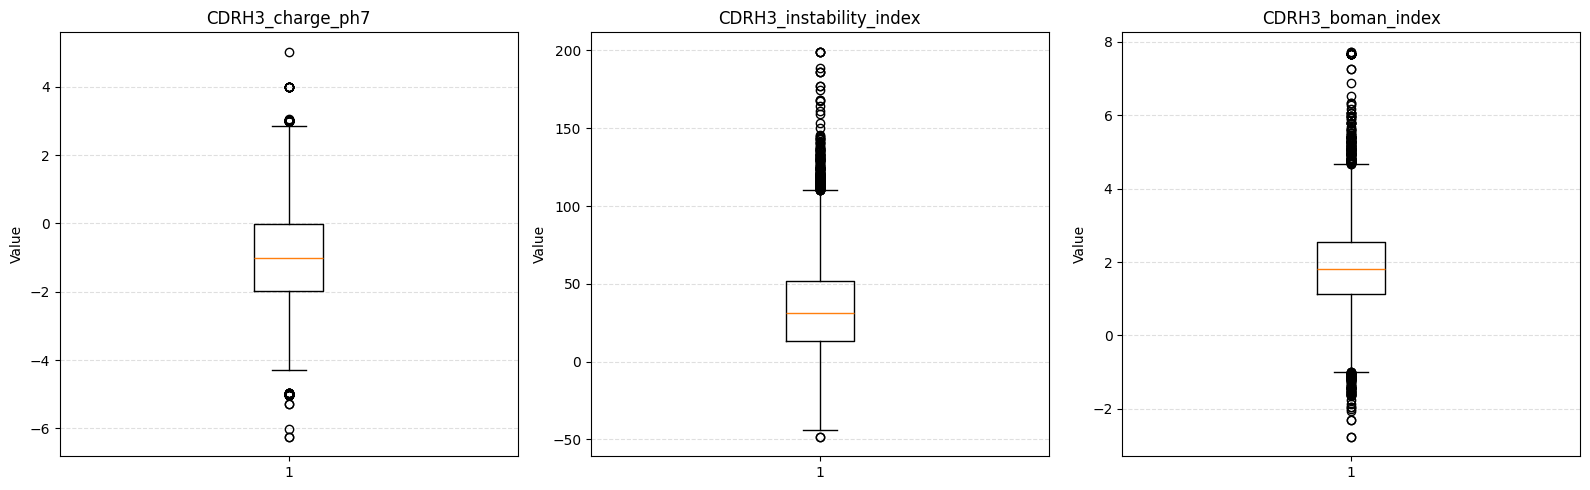

In [21]:
cdrh3_plot_cols = [
    "CDRH3_charge_ph7",
    "CDRH3_instability_index",
    "CDRH3_boman_index",
]

fig, axes = plt.subplots(1, len(cdrh3_plot_cols), figsize=(16, 5))

for ax, col in zip(axes, cdrh3_plot_cols):
    ax.boxplot(global_cdrh3_features[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel("Value")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In `charge_ph_7`, while there are indeed outliers, a -6.25 charge isn't exactly a mistake, and the fact that there are a few data points in this range suggests these may be biological extremes over actual data errors. This also applies to the `boman_index`

However, the instability index shows that even negative values are considered normal or not outliers, which is a big contradiction. We will take note of this for later. For now, let us find outliers for the other feature groups as well.

In [22]:
global_cdrl3_features = subset_region_features(global_features, "CDRL3")
global_cdrl3_features.describe()

,id,CDRL3_hydrophobicity,CDRL3_isoelectric_point,CDRL3_charge_ph7,CDRL3_molecular_weight,CDRL3_aliphatic_index,CDRL3_instability_index,CDRL3_aromaticity,CDRL3_boman_index,CDRL3_flexibility
count,17918.000000,16684.000000,16684.000000,16684.000000,16684.000000,16684.000000,16684.000000,16684.000000,16684.000000,16684.000000
mean,8958.500000,-0.949918,6.132955,-0.243060,1126.139880,43.636159,52.203541,0.160734,2.074122,0.075420
std,5172.625397,0.799080,2.044115,0.879836,149.834752,35.319613,38.454454,0.083807,1.221009,0.087952
min,0.000000,-3.500000,3.338526,-3.967170,247.207640,0.000000,-67.200000,0.000000,-2.526667,0.000000
25%,4479.250000,-1.544444,4.106574,-1.004916,1047.860365,0.000000,24.190000,0.100000,1.345889,0.000000
50%,8958.500000,-1.011111,6.093198,-0.007227,1120.244640,43.333333,51.627273,0.125000,1.995000,0.000000
75%,13437.750000,-0.400000,6.410150,-0.004924,1206.320165,70.909091,77.000000,0.222222,2.699167,0.177050
max,17917.000000,2.660000,12.807428,3.994141,2055.146940,214.000000,243.457143,0.625000,8.698000,0.505451


In [23]:
global_vhorvhh_features = subset_region_features(global_features, "VHorVHH")
global_vhorvhh_features.describe()

,id,VHorVHH_hydrophobicity,VHorVHH_isoelectric_point,VHorVHH_charge_ph7,VHorVHH_molecular_weight,VHorVHH_aliphatic_index,VHorVHH_instability_index,VHorVHH_aromaticity,VHorVHH_boman_index,VHorVHH_flexibility
count,17918.000000,17916.000000,17916.000000,17916.000000,17916.000000,17916.000000,17916.000000,17916.000000,17916.000000,17916.000000
mean,8958.500000,-0.408498,7.437297,0.562838,12799.483484,66.557420,33.667616,0.118475,1.689845,0.879700
std,5172.625397,0.704172,1.665095,2.022086,2869.776374,16.438995,10.560419,0.031517,1.363713,0.197812
min,0.000000,-3.500000,3.749987,-9.300607,247.207640,0.000000,1.023967,0.000000,0.651750,0.000000
25%,4479.250000,-0.340000,6.491198,-1.004916,13060.714815,64.488189,28.210564,0.110236,1.246090,0.921458
50%,8958.500000,-0.256667,8.169509,0.718931,13376.893940,69.603175,35.499213,0.123967,1.403725,0.923955
75%,13437.750000,-0.177846,8.663640,1.762308,13740.382515,74.453782,40.899219,0.136000,1.559475,0.926308
max,17917.000000,0.140164,10.320318,7.734066,24108.138240,97.416667,62.875167,0.190476,7.680000,0.959153


In [24]:
global_vl_features = subset_region_features(global_features, "VL")
global_vl_features.describe()

,id,VL_hydrophobicity,VL_isoelectric_point,VL_charge_ph7,VL_molecular_weight,VL_aliphatic_index,VL_instability_index,VL_aromaticity,VL_boman_index,VL_flexibility
count,17918.000000,16690.000000,16690.000000,16690.000000,16690.000000,16690.000000,16690.000000,16690.000000,16690.000000,16690.000000
mean,8958.500000,-0.808053,6.640550,-0.197182,9963.372704,58.151501,40.057703,0.086233,2.399836,0.782251
std,5172.625397,1.132243,1.967931,1.914632,4084.009634,24.847048,16.302706,0.037878,2.221757,0.328056
min,0.000000,-3.500000,3.749987,-9.261743,247.207640,0.000000,5.000000,0.000000,0.480550,0.000000
25%,4479.250000,-0.443750,4.628908,-1.263559,11409.477640,62.314815,37.631481,0.084906,1.373070,0.916119
50%,8958.500000,-0.358370,7.241056,-0.267849,11586.829390,67.476636,44.521691,0.100917,1.510639,0.918567
75%,13437.750000,-0.286111,8.657781,1.693696,11739.132940,71.121495,50.122523,0.110092,1.692635,0.921802
max,17917.000000,0.082243,11.084433,6.705109,23392.998140,98.396226,72.682243,0.158879,7.680000,0.962367


We also see possible outliers in `instability_index` and `boman_index` for CDRL3 very similar to CDRH3.

However, for VHorHH and VL, we do not see this `instability_index` discrepancy, with range 1.02 to 72.68. Similarly, their `charge_ph7` and `boman_index` goes beyond normal but not impossible and are possible biological extremes.

After furter searching, out of bounds values for instability index occurs due to mathematical quirks of the Guruprasad Algorithm. To put simply, instability index behaves well on full-length proteins (VL & VorVHH) but becomes unstable on short hypervariable regions (CDRL3 & CDRH3).

Therefore, these instances with abnormal instability indices will not be counted as outliers nor will these data points be removed. However, the ML model should **not** utilize instability_index for CDR regions. Hence, the classes CDRL3_instability_index & CDRH3_instability_index will be removed.

In [25]:
drop_cols = ["CDRH3_instability_index", "CDRL3_instability_index"]

global_features_cleaned = global_features.drop(columns=drop_cols, errors="ignore")

global_cdrh3_features = subset_region_features(global_features_cleaned, "CDRH3")
global_cdrl3_features = subset_region_features(global_features_cleaned, "CDRL3")
global_vhorvhh_features = subset_region_features(global_features_cleaned, "VHorVHH")
global_vl_features = subset_region_features(global_features_cleaned, "VL")

print("Dropped columns:", [c for c in drop_cols if c in global_features.columns])
print("Global physicochemical shape before:", global_features.shape)
print("Global physicochemical shape after:", global_features_cleaned.shape)

Dropped columns: ['CDRH3_instability_index', 'CDRL3_instability_index']
Global physicochemical shape before: (17918, 37)
Global physicochemical shape after: (17918, 35)


This cleaned dataset will then be saved in the `/cleaned_data` folder.

In [26]:
output_path = Path("cleaned_data/04_antibody_only_physicochemical_properties_cleaned.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
global_features_cleaned.to_csv(output_path, index=False)
print(f"Saved cleaned features to {output_path}")

Saved cleaned features to cleaned_data/04_antibody_only_physicochemical_properties_cleaned.csv


## Fin - Merge all subdatasets

Finally, merge all cleaned subdatasets via SQL equivalent of inner join to remove invalid rows.

In [ ]:
cleaned_dir = Path("cleaned_data")

labels_cleaned = pd.read_csv(cleaned_dir / "01_binding_labels_cleaned.csv")
naive_features_cleaned = pd.read_csv(cleaned_dir / "02_naive_processed_features_cleaned.csv")
conjoint_triads_cleaned = pd.read_csv(cleaned_dir / "03_conjoint_triads_processed_features_cleaned.csv")
global_features_cleaned = pd.read_csv(cleaned_dir / "04_antibody_only_physicochemical_properties_cleaned.csv")

for name, df in {
    "labels": labels_cleaned,
    "naive": naive_features_cleaned,
    "conjoint_triads": conjoint_triads_cleaned,
    "global_features": global_features_cleaned,
}.items():
    if "id" not in df.columns:
        raise KeyError(f"{name} is missing required column: 'id'")

merged_cleaned = (
    labels_cleaned
    .merge(naive_features_cleaned, on="id", how="inner")
    .merge(conjoint_triads_cleaned, on="id", how="inner")
    .merge(global_features_cleaned, on="id", how="inner")
)

output_path = cleaned_dir / "05_merged_cleaned_dataset.csv"
merged_cleaned.to_csv(output_path, index=False)

print("Input shapes:")
print(f"- labels: {labels_cleaned.shape}")
print(f"- naive: {naive_features_cleaned.shape}")
print(f"- conjoint triads: {conjoint_triads_cleaned.shape}")
print(f"- global features: {global_features_cleaned.shape}")
print(f"Merged shape: {merged_cleaned.shape}")
print(f"Saved merged cleaned dataset to {output_path}")

merged_cleaned.head(2)

Input shapes:
- labels: (12746, 6)
- naive: (17890, 92)
- conjoint triads: (17918, 1374)
- global features: (17918, 35)
Merged shape: (12718, 1504)
Saved merged cleaned dataset to cleaned_data/05_merged_cleaned_dataset.csv


,Unnamed: 0,id,is_binding_SARS-CoV2_WT,is_neutral_SARS-CoV2_WT,is_nanobody,name_x,CDRH3_len,CDRH3_amino_acid_percentage_A,CDRH3_amino_acid_percentage_C,CDRH3_amino_acid_percentage_D,...,VL_flexibility,VHorVHH_hydrophobicity,VHorVHH_isoelectric_point,VHorVHH_charge_ph7,VHorVHH_molecular_weight,VHorVHH_aliphatic_index,VHorVHH_instability_index,VHorVHH_aromaticity,VHorVHH_boman_index,VHorVHH_flexibility
0,0,0,1,1,0,Curtis_3548_S-2,13,0.076923,0.0,0.230769,...,0.0,-3.5,3.749987,-1.004916,247.20764,0.0,5.0,0.0,7.68,0.0
1,1,1,1,0,0,Curtis_3548_S-7,14,0.071429,0.0,0.071429,...,0.0,-3.5,3.749987,-1.004916,247.20764,0.0,5.0,0.0,7.68,0.0


In [28]:
merged_cleaned.shape

(12718, 1504)